In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

In [3]:
ds = xr.concat(datasets, dim='station')

# Bimonthly - select highest every 2 months
for independence

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 295
CSV_OUT = "gev_fit_scores.csv"
N_CLUSTERS = 3  # change if you want more/less clusters

if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if residual isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

# Helper to get the time dimension for a single-station DataArray
def _time_dim(da):
    # assume one non-station dimension is time
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

# Goodness-of-fit helpers
def kuiper_statistic(x, cdf_func):
    """
    Kuiper statistic V = D+ + D-
    x: 1D array of samples
    cdf_func: function mapping x -> F(x)
    """
    x = np.sort(np.asarray(x))
    n = x.size
    # empirical CDF points: i/n at each x_i
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)

    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    """
    R² between empirical CDF and model CDF.
    """
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)  # slightly less extreme than i/n
    F_mod = cdf_func(x)

    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

results = []

for s in stations:
    # DataArray for this station
    da = ds[TARGET_VAR].sel(station=s)

    # infer time dimension
    tdim = _time_dim(da)

    # drop NaNs/infs
    da = da.where(np.isfinite(da), drop=True)

    # require at least some data
    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # bimonthly maxima (2-month block maxima)
    # requires datetime-like index on the time dimension
    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    # Fit GEV: params = (c, loc, scale)
    gev_params = st.genextreme.fit(x)
    c, loc, scale = gev_params

    # CDF function for this fitted GEV
    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    # K-S statistic
    ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)

    # Kuiper statistic
    kuiper = kuiper_statistic(x, gev_cdf)

    # R² between empirical CDF and model CDF
    r2 = r2_cdf_fit(x, gev_cdf)

    lat, lon = _meta_for_station(s)

    results.append(
        {
            "station": int(s),
            "lat": lat,
            "lon": lon,
            "n_blocks": int(x.size),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "kuiper": kuiper,
            "r2_cdf": r2,
        }
    )

# Convert to DataFrame and save CSV
df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

Skipping station 110: not enough data after cleaning.
Skipping station 112: not enough data after cleaning.
Skipping station 113: not enough data after cleaning.
Skipping station 143: not enough data after cleaning.
Skipping station 145: not enough data after cleaning.
Skipping station 159: not enough data after cleaning.
Skipping station 276: not enough data after cleaning.
Skipping station 466: not enough data after cleaning.
Skipping station 472: not enough data after cleaning.
Skipping station 480: not enough data after cleaning.
Skipping station 518: not enough data after cleaning.
Skipping station 525: not enough data after cleaning.
Skipping station 557: not enough data after cleaning.
Skipping station 558: not enough data after cleaning.
Skipping station 564: not enough data after cleaning.
Skipping station 96: not enough data after cleaning.
Saved GEV fit parameters and scores to: gev_fit_scores.csv


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- after df is created (and non-empty) ---

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# 5) Choose k (either fixed or silhouette scan)
if N_CLUSTERS is None:
    k_range = range(2, 9)
    sil = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=0, n_init="auto")
        labels = km.fit_predict(Xs)
        sil[k] = silhouette_score(Xs, labels)
    best_k = max(sil, key=sil.get)
else:
    best_k = int(N_CLUSTERS)
    sil = None

# 6) Fit final KMeans
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)
print(summary)

# If you used silhouette scan, print it
if sil is not None:
    print("Silhouette scores:", sil)


Saved clustered GEV parameters to: gev_fit_scores_kmeans_gev_k3.csv
        gev_c                               gev_loc                      \
        count      mean    median       std   count      mean    median   
cluster                                                                   
0         122  0.167322  0.163491  0.157799     122  0.856617  0.861795   
1         136  0.029939  0.008879  0.254636     136  0.450909  0.452687   
2          21  0.952197  1.047822  0.250236      21  1.400381  1.493606   

                  gev_scale            ...   ks_stat           kuiper  \
              std     count      mean  ...    median       std  count   
cluster                                ...                              
0        0.199059       122  0.361995  ...  0.069045  0.030793    122   
1        0.299071       136  0.185973  ...  0.052924  0.032226    136   
2        0.363576        21  0.469140  ...  0.126299  0.066344     21   

                                      r2_c

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_68344/3195817003.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_clusters)


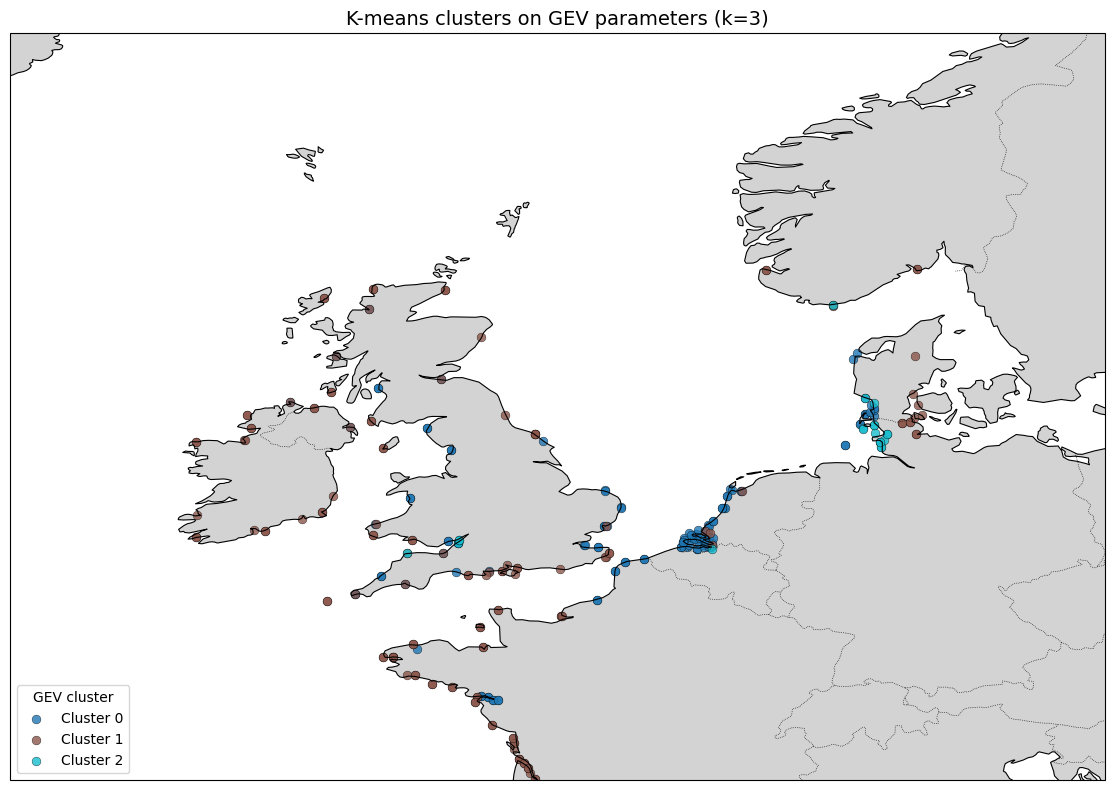

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- config ---
PROJECTION = ccrs.PlateCarree()
FIGSIZE = (12, 8)
POINT_SIZE = 40

# Safety checks
required_cols = {"lat", "lon", "cluster"}
missing = required_cols - set(dfc.columns)
if missing:
    raise ValueError(f"Missing required columns for mapping: {missing}")

# Drop rows without coordinates
plot_df = dfc.dropna(subset=["lat", "lon", "cluster"]).copy()

clusters = np.sort(plot_df["cluster"].unique())
n_clusters = len(clusters)

# Colormap with discrete colors
cmap = plt.cm.get_cmap("tab10", n_clusters)

# --- figure ---
fig = plt.figure(figsize=FIGSIZE)
ax = plt.axes(projection=PROJECTION)

# Map features
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

# Plot each cluster separately (clean legend control)
for c in clusters:
    sub = plot_df[plot_df["cluster"] == c]
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=POINT_SIZE,
        color=cmap(c),
        transform=ccrs.PlateCarree(),
        label=f"Cluster {c}",
        alpha=0.8,
        edgecolor="k",
        linewidth=0.3,
    )

# Legend
ax.legend(
    title="GEV cluster",
    loc="lower left",
    frameon=True,
)

ax.set_extent([-15,15,45,65])

# Title
ax.set_title(
    f"K-means clusters on GEV parameters (k={n_clusters})",
    fontsize=14,
)

plt.tight_layout()
plt.show()


In [13]:
dfc

,station,lat,lon,n_blocks,gev_c,gev_loc,gev_scale,ks_stat,ks_pvalue,kuiper,r2_cdf,cluster
0,1,48.383000,-4.495000,399,0.019139,0.396665,0.154269,0.024895,9.604563e-01,0.049499,0.998840,1
1,10,45.568480,-1.061555,237,0.008840,0.396950,0.213067,0.039537,8.380715e-01,0.076210,0.996165,1
2,102,50.102000,-5.542000,377,0.091521,0.382410,0.133945,0.028702,9.063368e-01,0.053232,0.998736,1
3,103,50.103000,-5.542750,448,0.182677,0.416630,0.338177,0.198556,5.918320e-16,0.348877,0.833575,0
4,104,50.099998,-5.533330,208,0.207246,0.355758,0.397802,0.227428,6.154688e-10,0.426214,0.779586,0
...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,49.930000,1.085000,354,0.134247,0.648707,0.249021,0.032957,8.242212e-01,0.060356,0.997792,0
275,94,49.481602,0.105600,334,-0.071086,0.606402,0.217723,0.049914,3.641023e-01,0.082405,0.994583,1
276,95,49.651299,-1.635500,307,0.041510,0.421703,0.156389,0.046830,4.964226e-01,0.092796,0.994417,1
277,97,49.183300,-2.116700,194,0.001364,0.500910,0.167137,0.047496,7.555074e-01,0.083306,0.995876,1


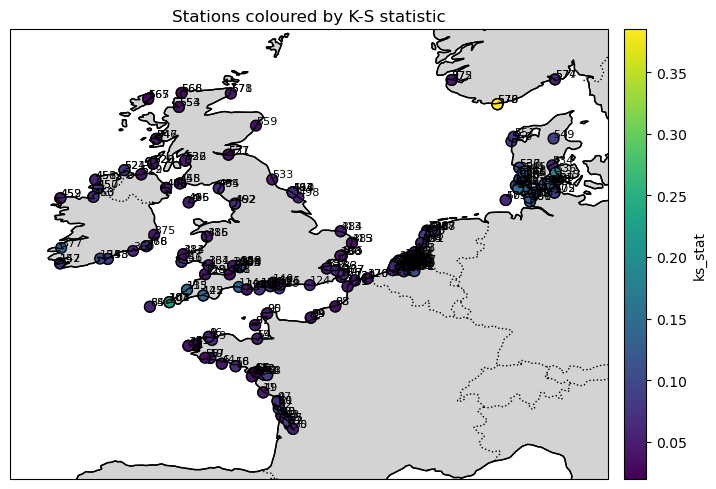

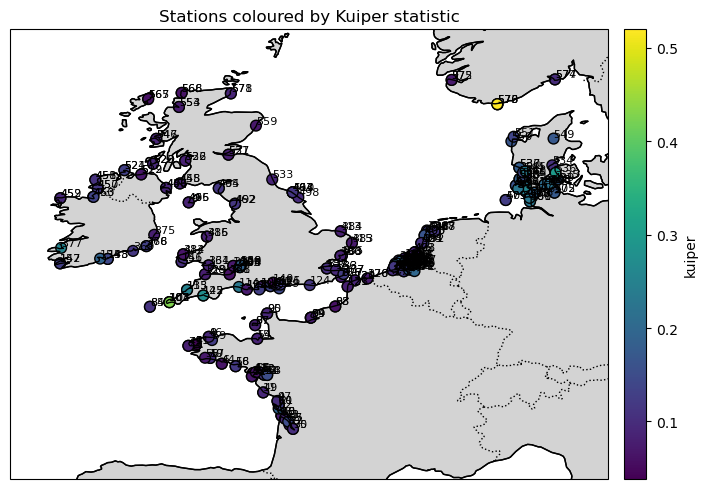

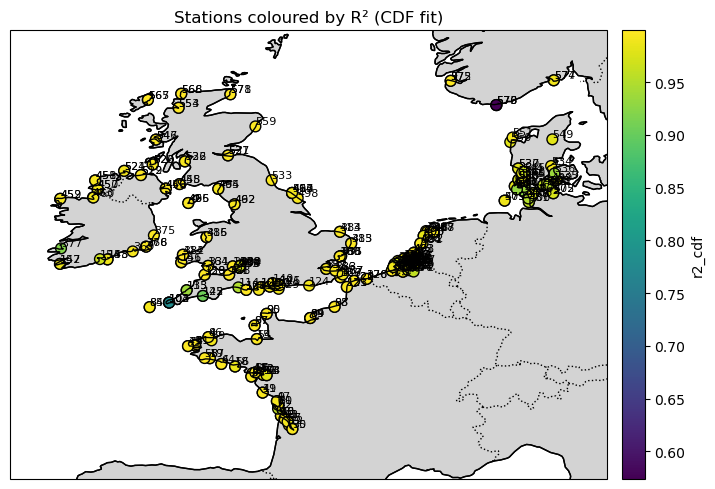

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# Drop stations without coordinates
df_map = df.dropna(subset=["lat", "lon"]).copy()

# --- helper to make a single metric map ---
def plot_metric_map(df, metric_col, title, cmap="viridis"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    # Land + coastlines
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Extent with some padding
    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    sc = ax.scatter(
        df["lon"], df["lat"],
        c=df[metric_col],
        s=60,
        transform=proj,
        cmap=cmap,
        edgecolor="k"
    )

    # station labels
    for _, row in df.iterrows():
        ax.text(
            row["lon"], row["lat"],
            str(int(row["station"])),
            transform=proj,
            fontsize=8,
            ha="left", va="bottom"
        )

    plt.title(title)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label(metric_col)
    plt.tight_layout()
    plt.show()


# --- maps coloured by KS, Kuiper, R² ---

plot_metric_map(df_map, "ks_stat", "Stations coloured by K-S statistic")
plot_metric_map(df_map, "kuiper", "Stations coloured by Kuiper statistic")
plot_metric_map(df_map, "r2_cdf", "Stations coloured by R² (CDF fit)")




k=2: silhouette score=0.6618
k=3: silhouette score=0.6270
k=4: silhouette score=0.5550
k=5: silhouette score=0.5553
k=6: silhouette score=0.5436
k=7: silhouette score=0.5296
k=8: silhouette score=0.4877


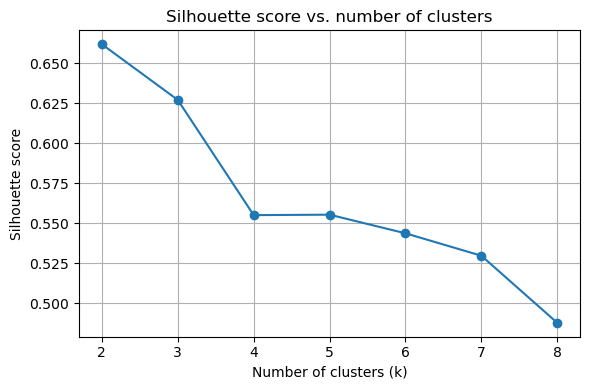

Best k by silhouette score: 2
Cluster counts with best k:
cluster
1    227
0     52
Name: count, dtype: int64


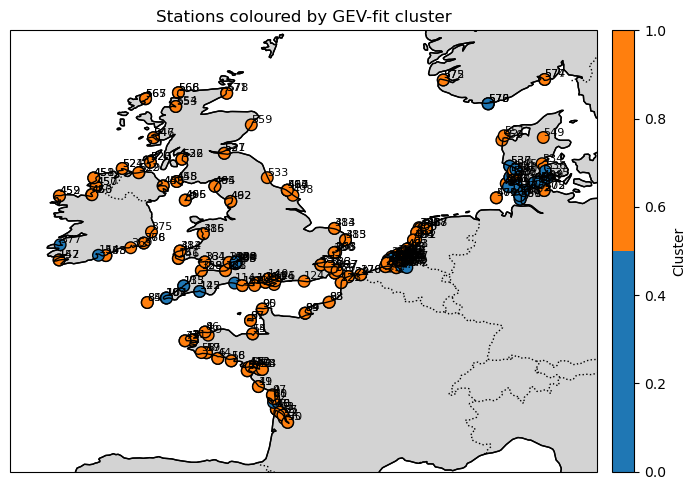

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X = df[["ks_stat", "kuiper", "r2_cdf"]].values

# Range of K to test
K_RANGE = range(2, 9)  # e.g. 2 to 8 clusters

sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k)
    sil_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")

# Plot silhouette score vs number of clusters
plt.figure(figsize=(6, 4))
plt.plot(list(K_RANGE), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs. number of clusters")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Optional: choose best k and re-cluster ---

best_k = K_RANGE[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X)
df["cluster"] = labels

print("Cluster counts with best k:")
print(df["cluster"].value_counts())

# --- map coloured by cluster (categorical) ---

from matplotlib.colors import ListedColormap

def plot_cluster_map(df, cluster_col="cluster", title="Station clusters"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Ensure cluster is int from 0..K-1
    clusters = df[cluster_col].astype(int).values
    n_clusters = len(np.unique(clusters))

    # Use a default qualitative colormap with at least n_clusters colors
    base_cmap = plt.get_cmap("tab10")
    colors = [base_cmap(i) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    sc = ax.scatter(
        df["lon"], df["lat"],
        c=clusters,
        s=70,
        transform=proj,
        cmap=cmap,
        edgecolor="k"
    )

    # station labels
    for _, row in df.iterrows():
        ax.text(
            row["lon"], row["lat"],
            str(int(row["station"])),
            transform=proj,
            fontsize=8,
            ha="left", va="bottom"
        )

    plt.title(title)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label("Cluster")
    plt.tight_layout()
    plt.show()


plot_cluster_map(df, cluster_col="cluster", title="Stations coloured by GEV-fit cluster")

In [13]:
# Ensure cluster column exists
if "cluster" not in df.columns:
    raise RuntimeError("df['cluster'] not found — run clustering first.")

# Columns to summarize
cols_to_summarize = [
    "ks_stat",
    "kuiper",
    "r2_cdf",
    "gev_c",
    "gev_loc",
    "gev_scale",
    "n_blocks"
]

# Compute cluster means
cluster_means = df.groupby("cluster")[cols_to_summarize].mean()

print("\n=== Mean Characteristics of Each Cluster ===\n")
print(cluster_means)



=== Mean Characteristics of Each Cluster ===

          ks_stat    kuiper    r2_cdf     gev_c   gev_loc  gev_scale  \
cluster                                                                
0        0.135890  0.241051  0.936277  0.455371  0.864366   0.398112   
1        0.059358  0.106123  0.991229  0.091638  0.662079   0.258176   

           n_blocks  
cluster              
0        142.480769  
1        192.083700  
